# Preprocessing

### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

### Loading Dataset

In [2]:
df = pd.read_csv("marketing_campaign.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524.0,1957.0,Graduation,Single,58138.0,0.0,0.0,04-09-2012,58.0,635.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,1.0
1,2174.0,1954.0,Graduation,Single,46344.0,1.0,1.0,08-03-2014,38.0,11.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
2,4141.0,1965.0,Graduation,Together,71613.0,0.0,0.0,21-08-2013,26.0,426.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
3,6182.0,1984.0,Graduation,Together,26646.0,1.0,0.0,10-02-2014,26.0,11.0,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0
4,5324.0,1981.0,PhD,Married,58293.0,1.0,0.0,19-01-2014,94.0,173.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0


### Dataset Inspection

In [3]:
df.shape

(3240, 29)

In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   float64
 1   Year_Birth           2240 non-null   float64
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   float64
 6   Teenhome             2240 non-null   float64
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   float64
 9   MntWines             2240 non-null   float64
 10  MntFruits            2240 non-null   float64
 11  MntMeatProducts      2240 non-null   float64
 12  MntFishProducts      2240 non-null   float64
 13  MntSweetProducts     2240 non-null   float64
 14  MntGoldProds         2240 non-null   float64
 15  NumDealsPurchases    2240 non-null   f

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### Handling Missing Values

In [7]:
df = df.dropna(subset=['ID'])
df = df.reset_index(drop=True)
df.shape

(2240, 29)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

### Handling Datatype

In [11]:
int_cols = [
    'Kidhome','Teenhome','Recency','NumDealsPurchases',
    'NumWebPurchases','NumCatalogPurchases','NumStorePurchases',
    'NumWebVisitsMonth','AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5','Complain','Response'
]

df[int_cols] = df[int_cols].astype(int)

In [12]:
df.drop(['Z_CostContact','Z_Revenue'], axis=1, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   float64
 1   Year_Birth           2240 non-null   float64
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   float64
 10  MntFruits            2240 non-null   float64
 11  MntMeatProducts      2240 non-null   float64
 12  MntFishProducts      2240 non-null   float64
 13  MntSweetProducts     2240 non-null   float64
 14  MntGoldProds         2240 non-null   float64
 15  NumDealsPurchases    2240 non-null   i

In [14]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [15]:
df['Dt_Customer'].head()

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]

### Feature Engineering

In [16]:
current_year = pd.Timestamp.now().year
df['Age'] = current_year - df['Year_Birth']

In [17]:
df.drop('Year_Birth', axis=1, inplace=True)

In [18]:
df['Customer_Tenure'] = (pd.Timestamp.now() - df['Dt_Customer']).dt.days

In [19]:
df.drop('Dt_Customer', axis=1, inplace=True)

In [20]:
df.drop(['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
         'AcceptedCmp4','AcceptedCmp5','Response'], axis=1, inplace=True)

In [21]:
df['Children'] = df['Kidhome'] + df['Teenhome']
df.drop(['Kidhome','Teenhome'], axis=1, inplace=True)

### Encoding Categorial Variables 

In [22]:
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

In [23]:
df.drop('ID', axis=1, inplace=True)

### Scaling the features

In [24]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Customer_Tenure,Children
0,-0.350141,0.251004,0.235696,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,-0.097282,0.985345,1.531185,-1.264505
1,-0.350141,0.251004,-0.235454,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,-0.097282,1.235733,-1.190545,1.396361
2,-0.350141,1.180340,0.773999,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,-0.097282,0.317643,-0.205773,-1.264505
3,-0.350141,1.180340,-1.022355,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-0.097282,-1.268149,-1.061881,0.065928
4,1.428354,-0.678332,0.241888,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-0.097282,-1.017761,-0.953012,0.065928


## Exploratory Data Analysis

In [25]:
df['Education'].value_counts()

Education
2    1127
4     486
3     370
0     203
1      54
Name: count, dtype: int64

In [26]:
df['Marital_Status'].value_counts()

Marital_Status
3    864
5    580
4    480
2    232
6     77
1      3
0      2
7      2
Name: count, dtype: int64

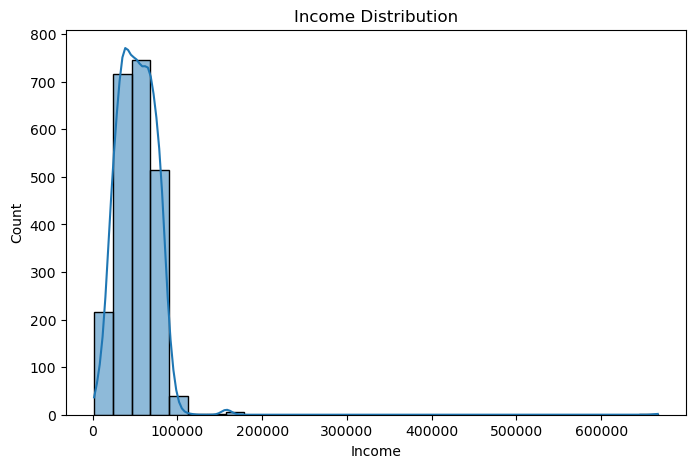

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

#### The income distribution is right-skewed, with most customers earning below 100,000. A few extremely high-income customers act as outliers, extending the distribution.

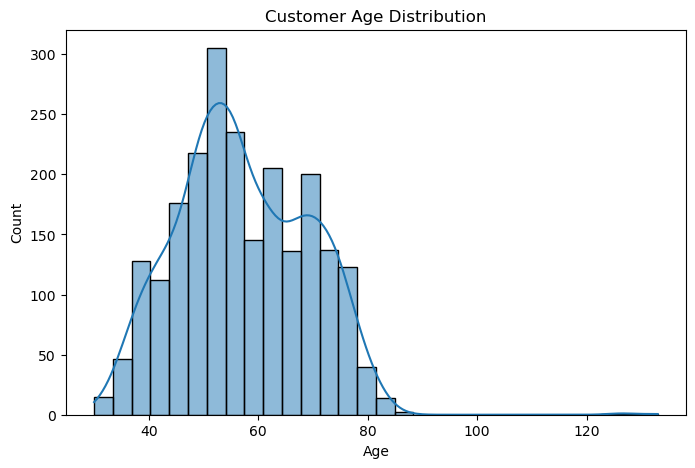

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Customer Age Distribution")
plt.show()

In [29]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)
df['Total_Spending'].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spending, dtype: float64

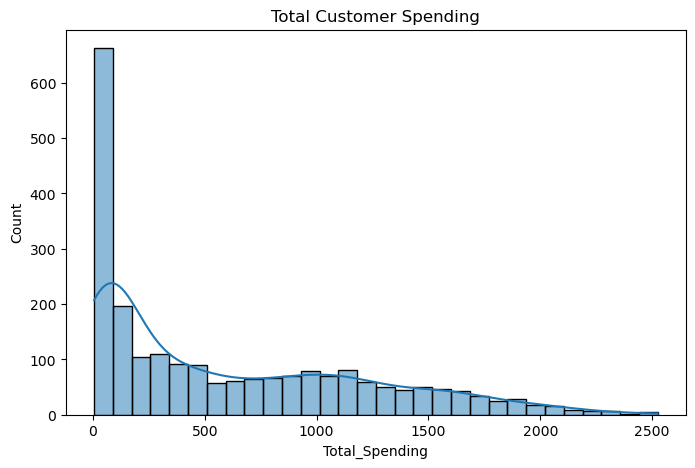

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title("Total Customer Spending")
plt.show()

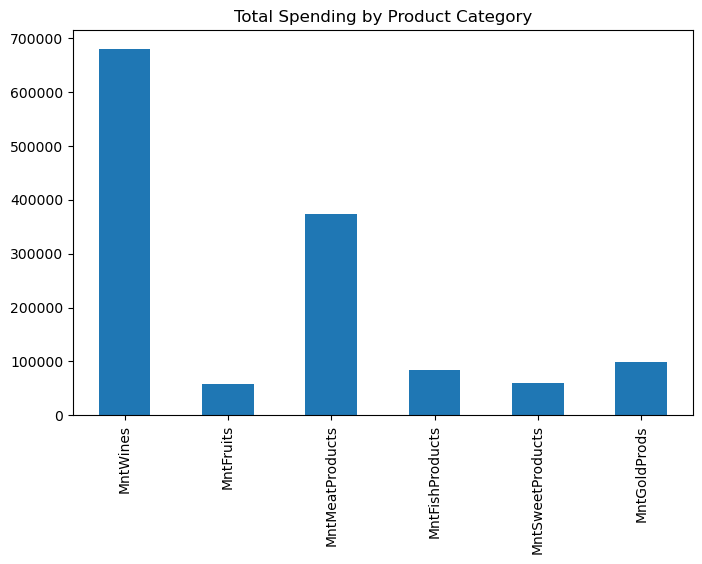

In [31]:
products = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]

df[products].sum().plot(kind='bar', figsize=(8,5))
plt.title("Total Spending by Product Category")
plt.show()

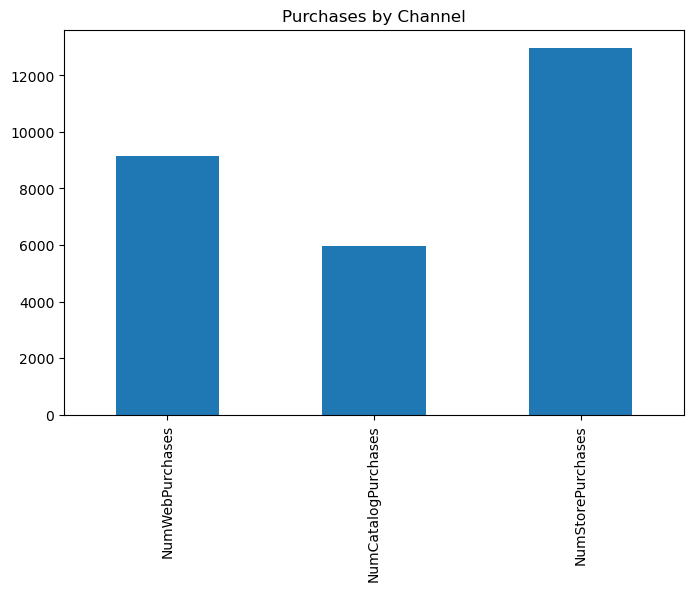

In [32]:
channels = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df[channels].sum().plot(kind='bar', figsize=(8,5))
plt.title("Purchases by Channel")
plt.show()

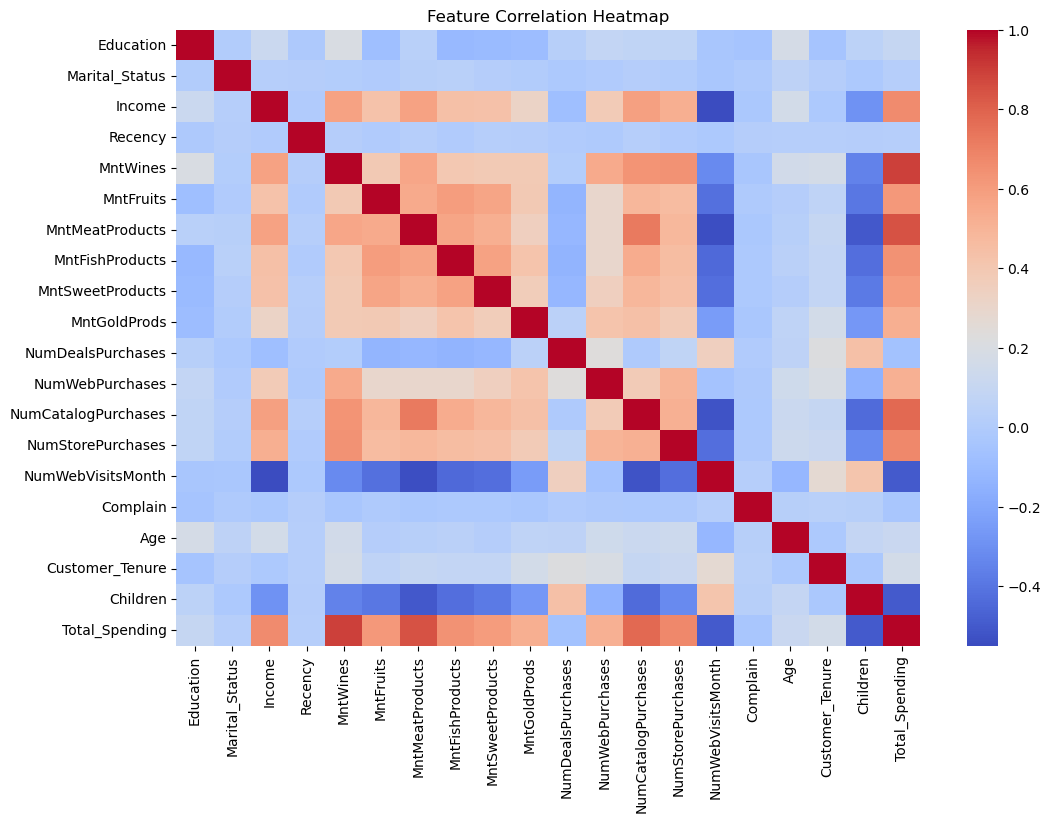

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

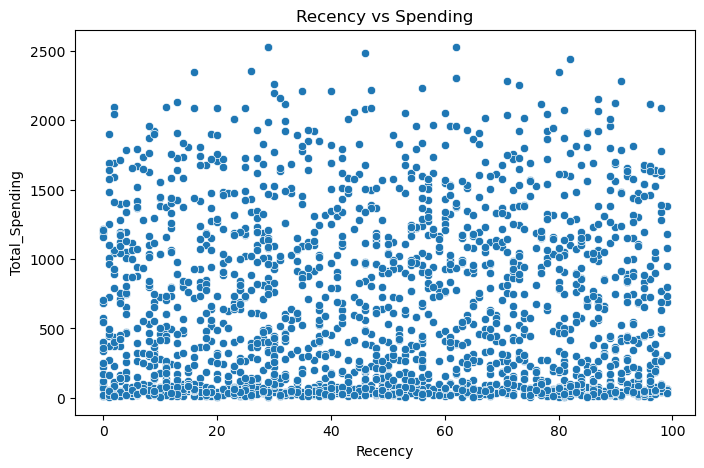

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Recency'], y=df['Total_Spending'])
plt.title("Recency vs Spending")
plt.show()

#### It is relationship between how recently a customer purchased and how much they spend. There is no strong linear relationship between recency and spending.
#### The scatter plot between Recency and Total Spending appears widely dispersed, indicating that there is no strong direct relationship between how recently a customer made a purchase and the amount they spend. Some customers who purchased recently have low spending, while some high-spending customers have not purchased for a long time. This variability suggests different customer purchasing patterns, which supports the need for clustering to identify meaningful customer segments.

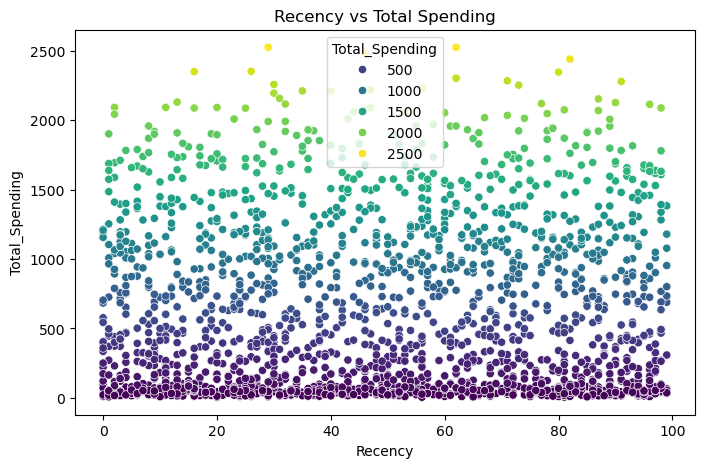

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Recency'], y=df['Total_Spending'], hue=df['Total_Spending'], palette='viridis')
plt.title("Recency vs Total Spending")
plt.show()

#### It helps highlight high-value customers.

### Outlier Detection

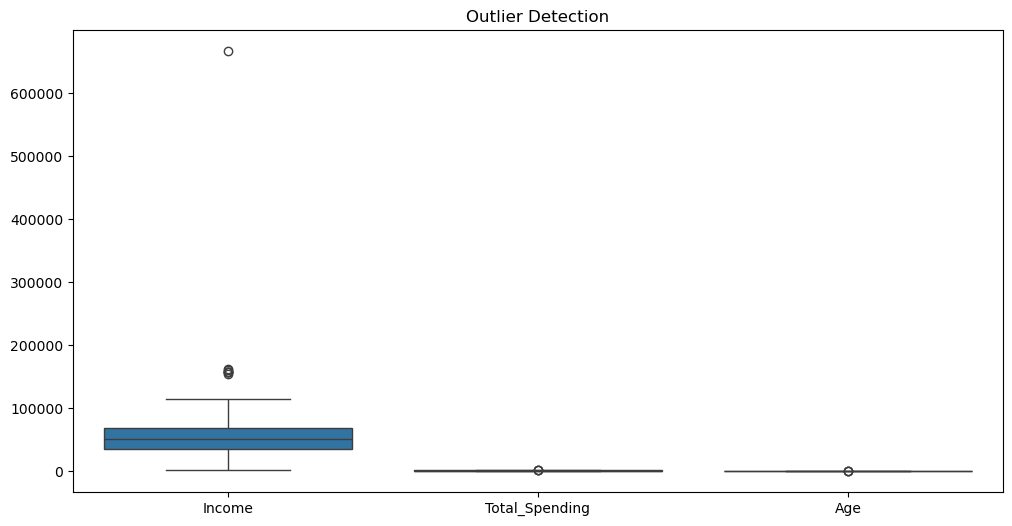

In [36]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Income','Total_Spending','Age']])
plt.title("Outlier Detection")
plt.show()

### Handling Outliers

In [37]:
outlier_cols = ['Income', 'Age', 'Total_Spending']
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
print("Outliers handled successfully.")

Outliers handled successfully.


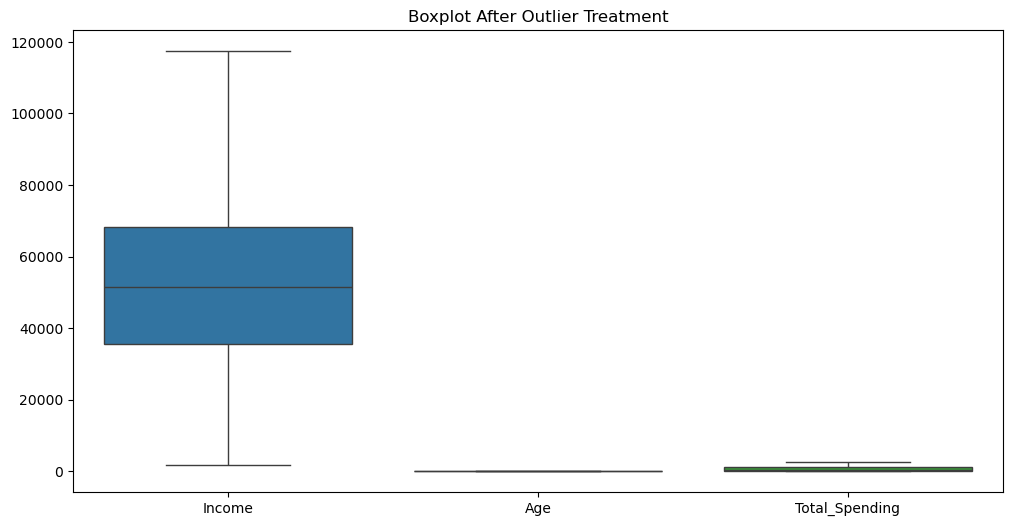

In [38]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Income','Age','Total_Spending']])
plt.title("Boxplot After Outlier Treatment")
plt.show()

### Elbow Method

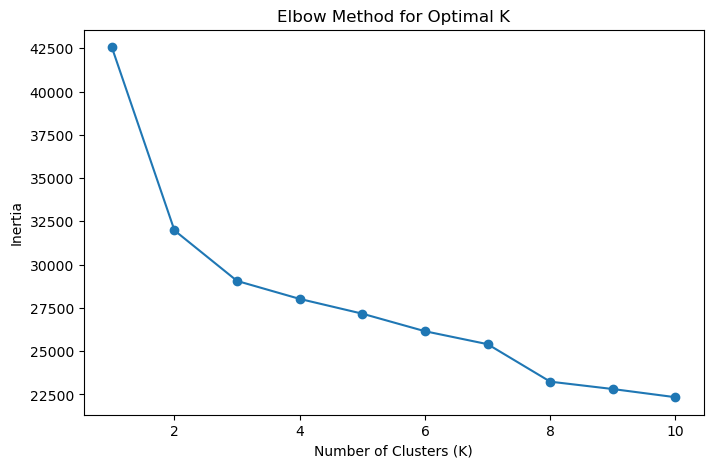

In [39]:
from sklearn.cluster import KMeans
inertia = []
K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

#### The Elbow Method was used to determine the optimal number of clusters. As the number of clusters increases, the within-cluster variance (inertia) decreases. The optimal number of clusters is identified at the point where the decrease begins to slow significantly, forming an “elbow” shape in the graph.

### Silhouette Method

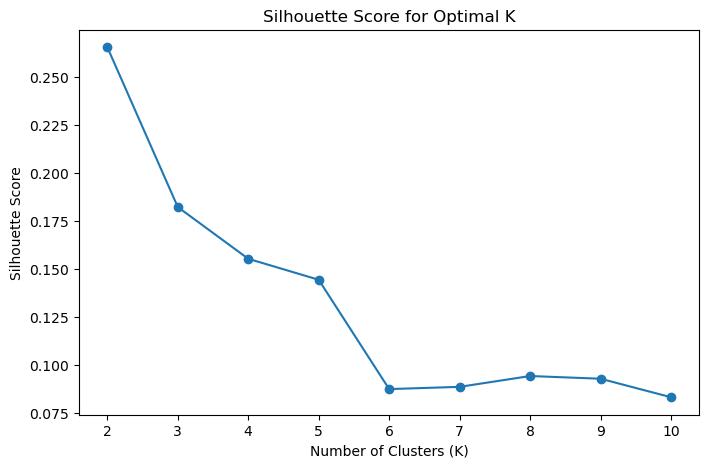

In [40]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal K")
plt.show()

## Model Comparison Using Multiple Clustering Algorithms

In [41]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_df)
df['Cluster'] = clusters
kmeans_score = silhouette_score(scaled_df, df['Cluster'])

In [42]:
df['Cluster'].value_counts()

Cluster
0    995
2    466
3    422
1    357
Name: count, dtype: int64

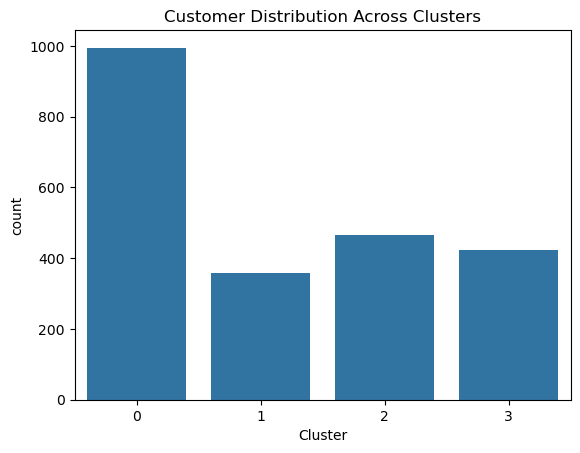

In [43]:
sns.countplot(x='Cluster', data=df)
plt.title("Customer Distribution Across Clusters")
plt.show()

In [44]:
from sklearn.cluster import AgglomerativeClustering
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(scaled_df)
agglo_score = silhouette_score(scaled_df, agglo_labels)
print("Agglomerative Score:", agglo_score)

Agglomerative Score: 0.1423882591580069


In [45]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df)
mask = dbscan_labels != -1
dbscan_score = silhouette_score(scaled_df[mask], dbscan_labels[mask])
print("DBSCAN Score:", dbscan_score)

DBSCAN Score: -0.08392580904362734


In [46]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(scaled_df)
from sklearn.metrics import silhouette_score
gmm_score = silhouette_score(scaled_df, gmm_labels)
print("GMM Score:", gmm_score)

GMM Score: 0.10092931949840113


In [47]:
print("KMeans:", kmeans_score)
print("Agglomerative:", agglo_score)
print("DBSCAN:", dbscan_score)
print("GMM:", gmm_score)

KMeans: 0.15532932005843056
Agglomerative: 0.1423882591580069
DBSCAN: -0.08392580904362734
GMM: 0.10092931949840113


## KMeans Model Evaluation

In [48]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(scaled_df, df['Cluster'])
print("Davies-Bouldin Index:", db_index)

Davies-Bouldin Index: 2.4488880097232153


#### The Davies–Bouldin Index obtained for the clustering model is approximately 2.45, indicating moderate cluster separation. Customer behavioral datasets typically contain overlapping characteristics, which leads to moderate separation between clusters. Despite this, the clustering model still provides useful segmentation insights for understanding customer purchasing behavior and designing targeted marketing strategies.

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_components, columns=['PC1','PC2'])
pca_df['Cluster'] = df['Cluster']

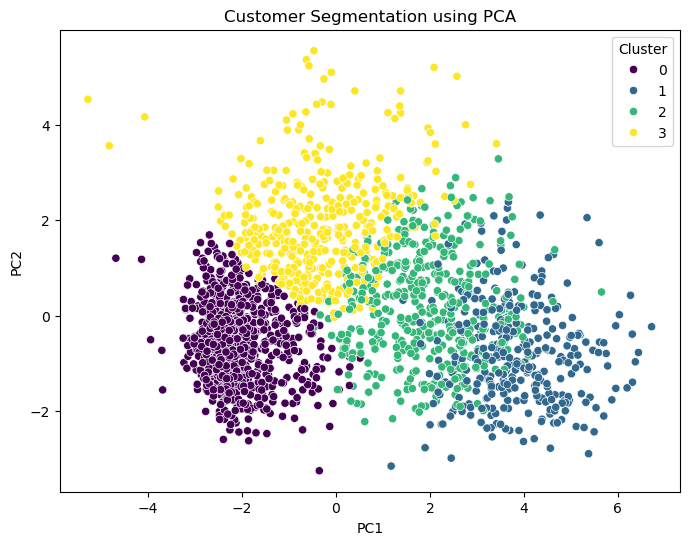

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='viridis'
)
plt.title("Customer Segmentation using PCA")
plt.show()

#### Principal Component Analysis (PCA) was used to reduce the high-dimensional dataset into two principal components while preserving the maximum variance in the data. This allows visualization of customer clusters in a two-dimensional space, making it easier to observe cluster separation and structure.

In [51]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.31343777 0.10036175]


#### The first principal component explains approximately 31.34% of the variance in the dataset, while the second explains 10.04%. Together, these two components capture around 41% of the total variance, allowing us to visualize the structure of the clusters in a two-dimensional space while preserving a significant portion of the original information.

In [52]:
important_cols = [
    'Income',
    'Total_Spending',
    'Recency',
    'NumStorePurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'Age',
    'Children'
]
cluster_summary = df.groupby('Cluster')[important_cols].mean().round(2)
cluster_summary

,Income,Total_Spending,Recency,NumStorePurchases,NumWebPurchases,NumCatalogPurchases,Age,Children
Cluster,,,,,,,,
0,34942.19,90.23,49.37,3.19,2.00,0.51,54.51,1.21
1,76062.94,1437.81,48.91,8.24,5.09,6.12,55.90,0.22
2,69646.52,1078.62,48.99,8.76,5.88,4.87,60.44,0.56
3,51664.29,595.34,48.80,6.58,6.17,2.36,60.79,1.39


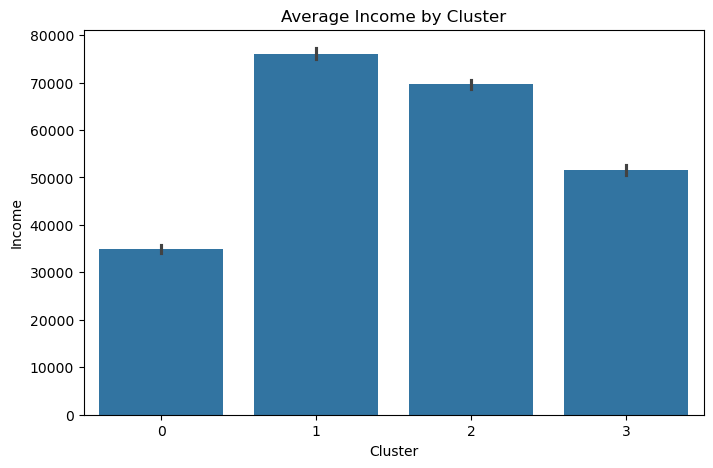

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(x='Cluster', y='Income', data=df)
plt.title("Average Income by Cluster")
plt.show()

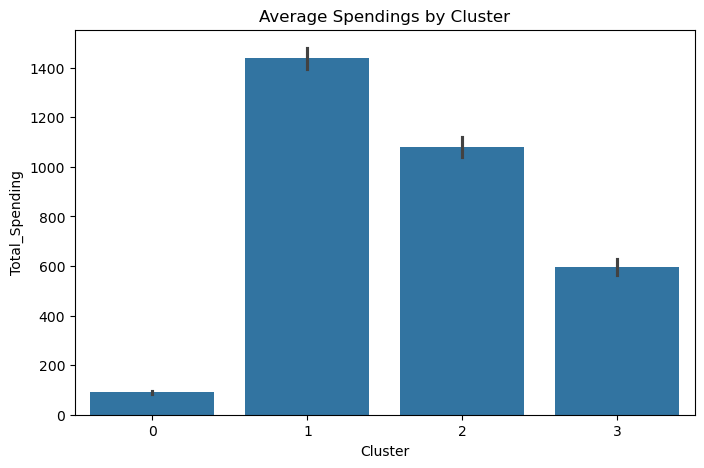

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(x='Cluster', y='Total_Spending', data=df)
plt.title("Average Spendings by Cluster")
plt.show()

In [55]:
features = [
    'Income',
    'Total_Spending',
    'Recency',
    'NumStorePurchases',
    'NumWebPurchases',
    'NumCatalogPurchases'
]
cluster_data = df.groupby('Cluster')[features].mean()

In [56]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cluster_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_data),
    columns=cluster_data.columns,
    index=cluster_data.index
)

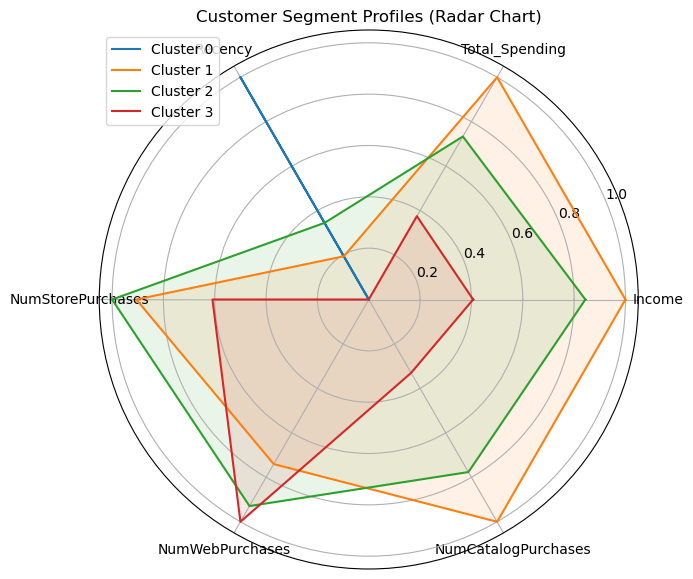

In [57]:
import numpy as np
labels = cluster_scaled.columns
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for i in cluster_scaled.index:
    
    values = cluster_scaled.loc[i].tolist()
    values += values[:1]
    
    ax.plot(angles, values, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Customer Segment Profiles (Radar Chart)")
plt.legend()
plt.show()

In [58]:
cluster_profile = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'NumStorePurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'Age',
    'Children'
]].mean()
cluster_profile

,Income,Total_Spending,NumStorePurchases,NumWebPurchases,NumCatalogPurchases,Age,Children
Cluster,,,,,,,
0,34942.191457,90.228141,3.186935,1.998995,0.514573,54.507538,1.209045
1,76062.943277,1437.811975,8.235294,5.089636,6.120448,55.899160,0.218487
2,69646.517704,1078.620172,8.759657,5.877682,4.866953,60.444206,0.560086
3,51664.290284,595.338863,6.580569,6.172986,2.364929,60.789100,1.390995


In [59]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cluster_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

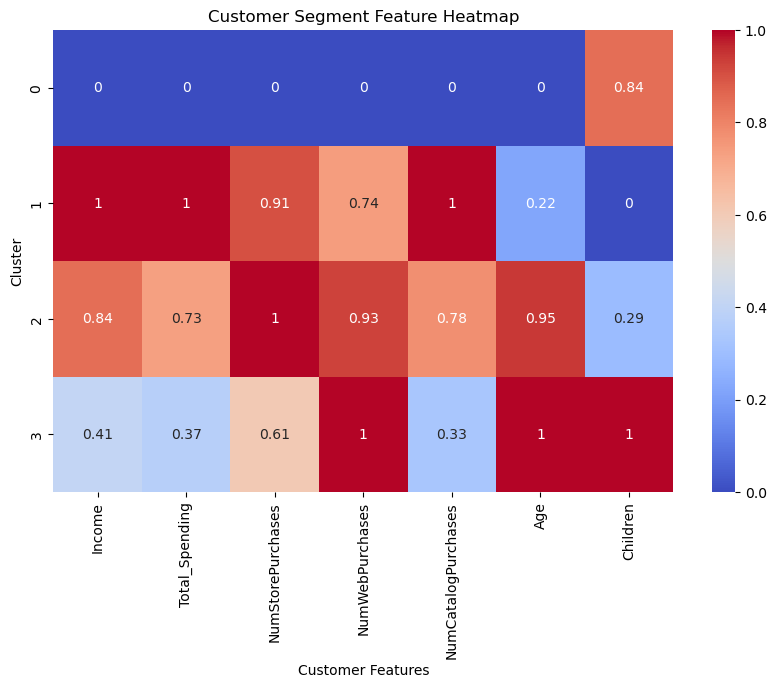

In [60]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_scaled,
    annot=True,
    cmap='coolwarm'
)
plt.title("Customer Segment Feature Heatmap")
plt.xlabel("Customer Features")
plt.ylabel("Cluster")
plt.show()

In [61]:
cluster_names = {
    0: "Low Value Families",
    1: "Premium Customers",
    2: "Store-Oriented Customers",
    3: "Online Customers"
}
df['Customer_Segment'] = df['Cluster'].map(cluster_names)
df[['Cluster','Customer_Segment']].drop_duplicates().sort_values('Cluster')

,Cluster,Customer_Segment
1,0,Low Value Families
0,1,Premium Customers
2,2,Store-Oriented Customers
4,3,Online Customers


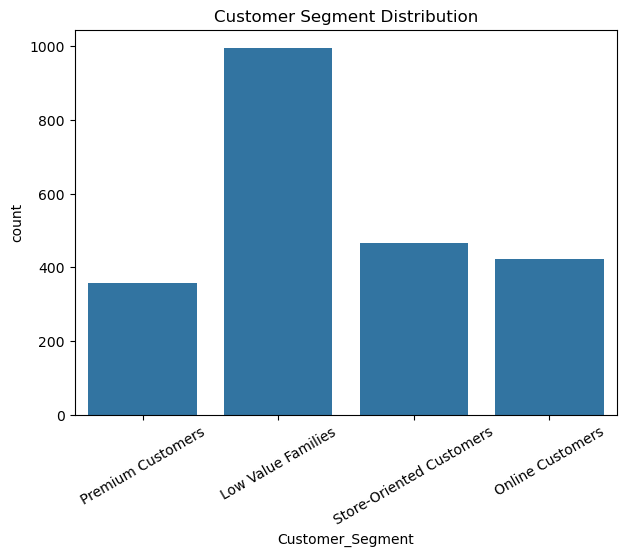

In [62]:
plt.figure(figsize=(7,5))
sns.countplot(x='Customer_Segment', data=df)
plt.title("Customer Segment Distribution")
plt.xticks(rotation=30)
plt.show()

## Classification Model

In [63]:
important_cols = [
    'Income',
    'Total_Spending',
    'Recency',
    'NumStorePurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'Age',
    'Children'
]

X = df[important_cols]
y = df['Cluster']

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [66]:
y_pred = clf.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8325892857142857


### Logistic Regressor

In [68]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.71875


### Decision Tree

In [69]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8035714285714286


In [70]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred))

Logistic Regression: 0.71875
Decision Tree: 0.8035714285714286
Random Forest: 0.8325892857142857


## Deployment

In [71]:
import joblib
joblib.dump(clf, "model.pkl")

['model.pkl']

In [72]:
df.to_csv("final_data.csv", index=False)